In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("synthetic_healthcare_data.csv")

In [4]:
print(df.head())

  Patient_ID  Age  Gender   BMI Blood_Pressure  Cholesterol_Level Smoker  \
0       P001   20  Female  24.7       104 / 72                245     No   
1       P002   47    Male  38.5       147 / 88                268    Yes   
2       P003   21    Male  18.5       145 / 65                199     No   
3       P004   57    Male  24.1       166 / 66                271    Yes   
4       P005   28    Male  22.5       176 / 71                197    Yes   

  Diabetic     Diagnosis  Treatment_Cost Admission_Date Discharge_Date  \
0      Yes      Diabetes         3328.60     2025-01-20     2025-02-01   
1       No      Diabetes         1041.69     2025-07-01     2025-07-04   
2      Yes  Hypertension          909.11     2025-06-28     2025-07-06   
3      Yes  Hypertension         1920.12     2025-02-10     2025-02-18   
4       No           Flu         3224.12     2025-04-18     2025-04-27   

     Outcome  
0  Recovered  
1   Referred  
2   Referred  
3   Deceases  
4   Deceases  


In [5]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Blood_Pressure',
       'Cholesterol_Level', 'Smoker', 'Diabetic', 'Diagnosis',
       'Treatment_Cost', 'Admission_Date', 'Discharge_Date', 'Outcome'],
      dtype='object')


In [6]:
df = pd.read_csv("synthetic_healthcare_data.csv")

df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])
df['Length_of_Stay'] = (df['Discharge_Date'] - df['Admission_Date']).dt.days

df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure'].str.split(' / ', expand=True).astype(float)

df = pd.get_dummies(df, columns=['Gender', 'Smoker', 'Diabetic', 'Diagnosis', 'Outcome'], drop_first=True)

In [7]:
print(df.head())

  Patient_ID  Age   BMI Blood_Pressure  Cholesterol_Level  Treatment_Cost  \
0       P001   20  24.7       104 / 72                245         3328.60   
1       P002   47  38.5       147 / 88                268         1041.69   
2       P003   21  18.5       145 / 65                199          909.11   
3       P004   57  24.1       166 / 66                271         1920.12   
4       P005   28  22.5       176 / 71                197         3224.12   

  Admission_Date Discharge_Date  Length_of_Stay  Systolic_BP  Diastolic_BP  \
0     2025-01-20     2025-02-01              12        104.0          72.0   
1     2025-07-01     2025-07-04               3        147.0          88.0   
2     2025-06-28     2025-07-06               8        145.0          65.0   
3     2025-02-10     2025-02-18               8        166.0          66.0   
4     2025-04-18     2025-04-27               9        176.0          71.0   

   Gender_Male  Smoker_Yes  Diabetic_Yes  Diagnosis_Flu  \
0        

In [8]:
df_raw = pd.read_csv("synthetic_healthcare_data.csv")
avg_cost = df_raw.groupby("Diagnosis")["Treatment_Cost"].mean()

print(avg_cost)

Diagnosis
Diabetes         2398.244348
Flu              2544.422941
Heart Disease    2665.428889
Hypertension     2600.243113
Pneumonia        2400.244519
Name: Treatment_Cost, dtype: float64


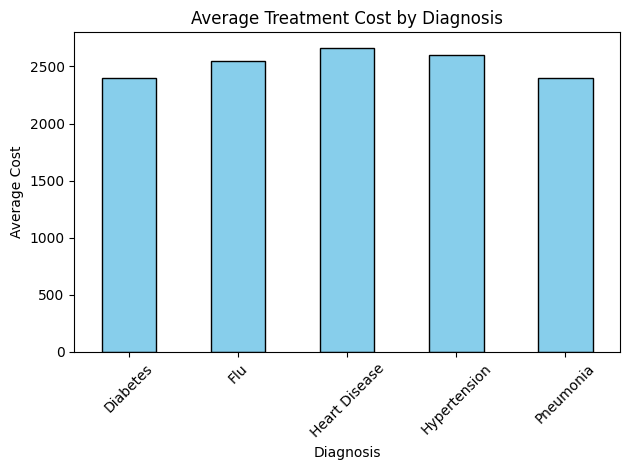

In [8]:
avg_cost = df_raw.groupby("Diagnosis")["Treatment_Cost"].mean()
avg_cost.plot(kind="bar", color='skyblue', edgecolor='black')
plt.title("Average Treatment Cost by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Average Cost")
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [9]:
smoker_cost = df_raw.groupby("Smoker")["Treatment_Cost"].mean()

print(smoker_cost)

Smoker
No     2608.160989
Yes    2410.411435
Name: Treatment_Cost, dtype: float64


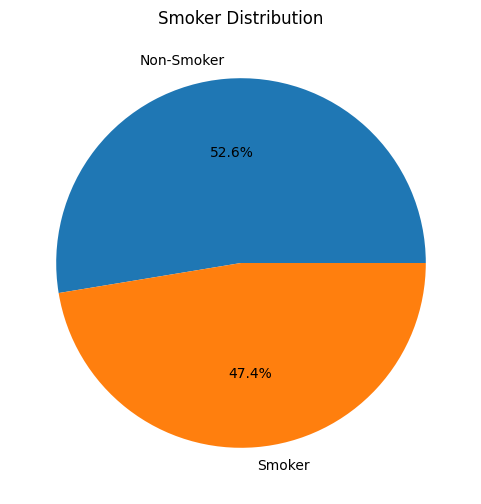

In [10]:
smoker_count = df_raw["Smoker"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    smoker_count,
    labels=["Non-Smoker", "Smoker"],
    autopct='%1.1f%%'
)

plt.title("Smoker Distribution")

plt.show()

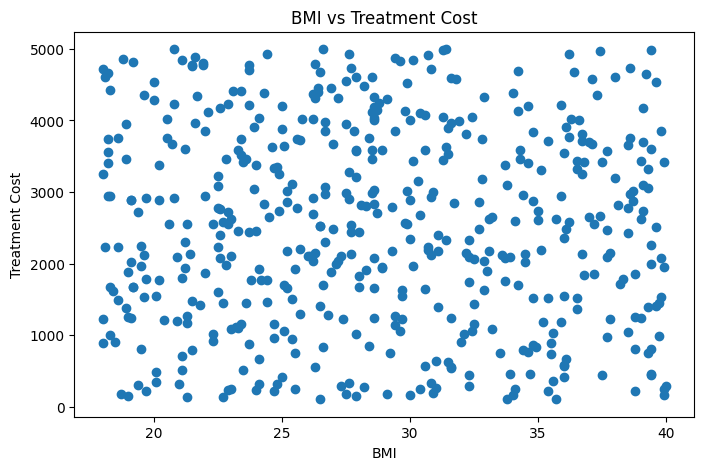

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["BMI"],
    df["Treatment_Cost"]
)

plt.xlabel("BMI")

plt.ylabel("Treatment Cost")

plt.title("BMI vs Treatment Cost")

plt.show()

In [9]:
X = df[[
    "Age", 
    "BMI", 
    "Cholesterol_Level", 
    "Length_of_Stay",          
    "Systolic_BP",           
    "Diastolic_BP",            
    "Gender_Male",             
    "Smoker_Yes",             
    "Diabetic_Yes",         
    "Diagnosis_Flu",           
    "Diagnosis_Heart Disease",
    "Diagnosis_Hypertension", 
    "Diagnosis_Pneumonia"     
]]

y = df["Treatment_Cost"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
predictions = model.predict(X_test)

print(predictions[:5])

[2806.9174  2787.89905 2763.60655 2500.22785 2805.9154 ]


In [13]:
error = mean_absolute_error(y_test, predictions)

print("MAE:", error)

MAE: 1256.7391825


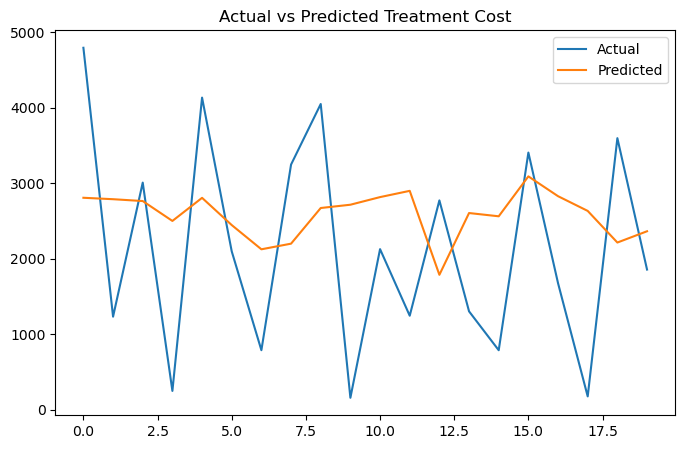

In [14]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:20], label="Actual")
plt.plot(predictions[:20], label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Treatment Cost")

plt.show()

In [18]:
new_patient = pd.DataFrame({
    "Age": [60],
    "BMI": [32],
    "Cholesterol_Level": [240],
    "Length_of_Stay": [12],       
    "Systolic_BP": [130.0],      
    "Diastolic_BP": [85.0],       
    "Gender_Male": [1],          
    "Smoker_Yes": [1],           
    "Diabetic_Yes": [1],      
    "Diagnosis_Flu": [0],         
    "Diagnosis_Heart Disease": [1], 
    "Diagnosis_Hypertension": [0],  
    "Diagnosis_Pneumonia": [0]      
})

predicted_cost = model.predict(new_patient)
print(predicted_cost)

[2561.6341]


In [19]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print(score)

-0.006392406618133117


# Test dự đoán với bệnh nhân mới

In [20]:
# 1. Người có hút thuốc
patient1 = pd.DataFrame({
    "Age": [55],
    "BMI": [30],
    "Cholesterol_Level": [220],
    "Length_of_Stay": [8],        
    "Systolic_BP": [120.0],      
    "Diastolic_BP": [80.0],    
    "Gender_Male": [1],            
    "Smoker_Yes": [1],             
    "Diabetic_Yes": [0],           
    "Diagnosis_Flu": [1],          
    "Diagnosis_Heart Disease": [0],
    "Diagnosis_Hypertension": [0],
    "Diagnosis_Pneumonia": [0]
})

# 2. Người không hút thuốc 
patient2 = pd.DataFrame({
    "Age": [55],
    "BMI": [30],
    "Cholesterol_Level": [220],
    "Length_of_Stay": [8],
    "Systolic_BP": [120.0],
    "Diastolic_BP": [80.0],
    "Gender_Male": [1],
    "Smoker_Yes": [0],             
    "Diabetic_Yes": [0],
    "Diagnosis_Flu": [1],
    "Diagnosis_Heart Disease": [0],
    "Diagnosis_Hypertension": [0],
    "Diagnosis_Pneumonia": [0]
})

print("Chi phí dự đoán người hút thuốc:", model.predict(patient1))
print("Chi phí dự đoán người KHÔNG hút thuốc:", model.predict(patient2))

Chi phí dự đoán người hút thuốc: [3003.79205]
Chi phí dự đoán người KHÔNG hút thuốc: [2899.85875]
